# 3.2 Clean Data — Titanic Survival Prediction

> **CRISP-DM Phase:** 3. Data Preparation | **Task:** 3.2 Clean Data
>
> This notebook addresses all data quality issues identified in [2.4 Data Quality Report](../docs/crisp-dm/2-data-understanding/2.4-data-quality.md) and applies cleaning operations to the selected data from [3.1 Data Selection](../docs/crisp-dm/3-data-preparation/3.1-select-data.md).

**Cleaning scope:**
1. **Age** (20% missing, MAR) — title-group median imputation + `AgeMissing` indicator
2. **Embarked** (2 missing in train, MCAR) — mode imputation ('S')
3. **Fare** (1 missing in test, MCAR) — Pclass-conditional median imputation

**Key guards:**
- All imputation parameters fit on **training data only**
- Raw data is **never modified** — outputs go to `data/processed/`
- Cleaning code lives in `src/cleaning.py` for reuse

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
if (PROJECT_ROOT / "notebooks").is_dir():
    pass  # cwd is project root
elif (PROJECT_ROOT.parent / "notebooks").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent  # cwd is a subdirectory

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "titanic"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Add src/ to path for imports
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.cleaning import clean_dataset, compute_imputation_params, extract_title, map_rare_titles

pd.set_option("display.max_columns", 15)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")

Project root: /Users/tba8ydd/Documents/claude-template
Data dir: /Users/tba8ydd/Documents/claude-template/data/raw/titanic


## 1. Load Raw Data

In [2]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {train_raw.shape[0]} rows × {train_raw.shape[1]} cols")
print(f"Test:  {test_raw.shape[0]} rows × {test_raw.shape[1]} cols")

Train: 891 rows × 12 cols
Test:  418 rows × 11 cols


## 2. Before-Cleaning: Missing Value Inventory

Baseline statistics before any cleaning is applied.

In [3]:
def missing_summary(df, name):
    """Show missing value counts and percentages for fields with any missing."""
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({"missing_count": missing, "missing_pct": pct})
    summary = summary.sort_values("missing_count", ascending=False)
    print(f"\n--- {name} ---")
    if summary.empty:
        print("No missing values.")
    else:
        print(summary.to_string())
    return summary

before_train = missing_summary(train_raw, "Train (before cleaning)")
before_test = missing_summary(test_raw, "Test (before cleaning)")


--- Train (before cleaning) ---
          missing_count  missing_pct
Cabin               687         77.1
Age                 177         19.9
Embarked              2          0.2

--- Test (before cleaning) ---
       missing_count  missing_pct
Cabin            327         78.2
Age               86         20.6
Fare               1          0.2


## 3. Compute Imputation Parameters (Train Only)

All imputation statistics are derived from the training set to prevent data leakage.

In [4]:
params = compute_imputation_params(train_raw)

print("Age medians by title group (from train):")
for title, med in sorted(params["age_medians_by_title"].items()):
    print(f"  {title}: {med}")

print(f"\nEmbarked mode (from train): '{params['embarked_mode']}'")

print("\nFare medians by Pclass (from train):")
for pclass, med in sorted(params["fare_medians_by_pclass"].items()):
    print(f"  Pclass {pclass}: {med:.4f}")

Age medians by title group (from train):
  Master: 3.5
  Miss: 21.0
  Mr: 30.0
  Mrs: 35.0

Embarked mode (from train): 'S'

Fare medians by Pclass (from train):
  Pclass 1: 60.2875
  Pclass 2: 14.2500
  Pclass 3: 8.0500


## 4. Apply Cleaning

Apply `clean_dataset()` from `src/cleaning.py` to both train and test using the parameters computed above.

In [5]:
train_clean = clean_dataset(train_raw, params)
test_clean = clean_dataset(test_raw, params)

print(f"Train clean: {train_clean.shape[0]} rows × {train_clean.shape[1]} cols")
print(f"Test clean:  {test_clean.shape[0]} rows × {test_clean.shape[1]} cols")

Train clean: 891 rows × 13 cols
Test clean:  418 rows × 12 cols


## 5. After-Cleaning: Validation

### 5.1 Missing Value Check

In [6]:
after_train = missing_summary(train_clean, "Train (after cleaning)")
after_test = missing_summary(test_clean, "Test (after cleaning)")

# Verify: only Cabin should still have missing values (deferred to 3.3)
for name, df in [("Train", train_clean), ("Test", test_clean)]:
    remaining = df.drop(columns=["Cabin"]).isnull().sum().sum()
    assert remaining == 0, f"{name} has {remaining} missing values outside Cabin!"
    print(f"✓ {name}: zero missing values (excluding Cabin, deferred to 3.3)")


--- Train (after cleaning) ---
       missing_count  missing_pct
Cabin            687         77.1

--- Test (after cleaning) ---
       missing_count  missing_pct
Cabin            327         78.2
✓ Train: zero missing values (excluding Cabin, deferred to 3.3)
✓ Test: zero missing values (excluding Cabin, deferred to 3.3)


### 5.2 Before vs. After Comparison

In [7]:
def before_after_table(raw, clean, label):
    """Compare key metrics before and after cleaning."""
    rows = {
        "Total records": (len(raw), len(clean)),
        "Total fields": (raw.shape[1], clean.shape[1]),
        "Records with any missing": (
            raw.isnull().any(axis=1).sum(),
            clean.isnull().any(axis=1).sum(),
        ),
        "Total missing values": (
            raw.isnull().sum().sum(),
            clean.isnull().sum().sum(),
        ),
        "Total missing (excl. Cabin)": (
            raw.drop(columns=["Cabin"]).isnull().sum().sum(),
            clean.drop(columns=["Cabin"]).isnull().sum().sum(),
        ),
    }
    df = pd.DataFrame(rows, index=["Before", "After"]).T
    df["Change"] = df["After"] - df["Before"]
    print(f"\n--- {label} ---")
    print(df.to_string())
    return df

ba_train = before_after_table(train_raw, train_clean, "Train")
ba_test = before_after_table(test_raw, test_clean, "Test")


--- Train ---
                             Before  After  Change
Total records                   891    891       0
Total fields                     12     13       1
Records with any missing        708    687     -21
Total missing values            866    687    -179
Total missing (excl. Cabin)     179      0    -179

--- Test ---
                             Before  After  Change
Total records                   418    418       0
Total fields                     11     12       1
Records with any missing        331    327      -4
Total missing values            414    327     -87
Total missing (excl. Cabin)      87      0     -87


### 5.3 Target Variable Impact

Verify that cleaning did not alter the target distribution (no records were dropped, target was never imputed).

In [8]:
print("Target distribution — before cleaning:")
print(train_raw["Survived"].value_counts(normalize=True).round(4))
print(f"\nTarget distribution — after cleaning:")
print(train_clean["Survived"].value_counts(normalize=True).round(4))

assert train_raw["Survived"].equals(train_clean["Survived"]), "Target column was modified!"
print("\n✓ Target column is identical before and after cleaning (no records dropped, no imputation).")

Target distribution — before cleaning:
Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

Target distribution — after cleaning:
Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

✓ Target column is identical before and after cleaning (no records dropped, no imputation).


### 5.4 Age Distribution Before vs. After Imputation

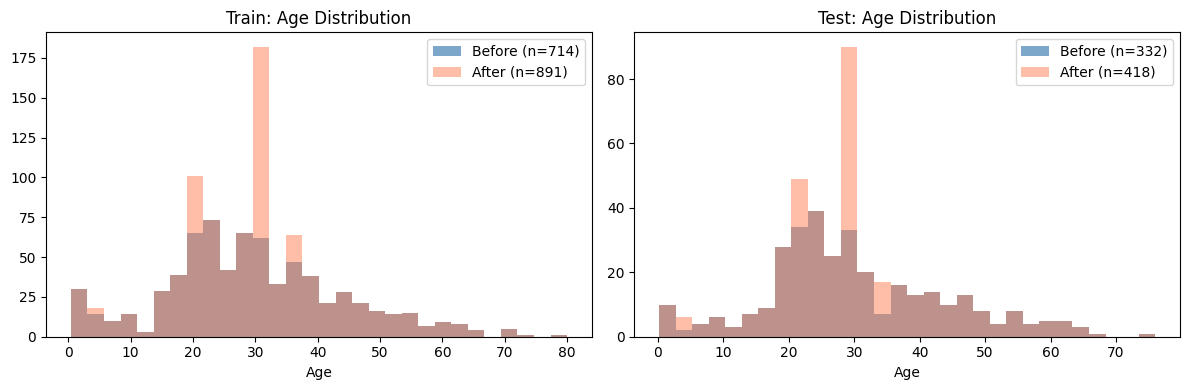

Train Age stats — before: {'count': 714.0, 'mean': 29.7, 'std': 14.53, 'min': 0.42, '25%': 20.12, '50%': 28.0, '75%': 38.0, 'max': 80.0}
Train Age stats — after:  {'count': 891.0, 'mean': 29.37, 'std': 13.25, 'min': 0.42, '25%': 21.0, '50%': 30.0, '75%': 35.0, 'max': 80.0}


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_raw["Age"].dropna(), bins=30, alpha=0.7, label="Before (n=714)", color="steelblue")
axes[0].hist(train_clean["Age"], bins=30, alpha=0.5, label="After (n=891)", color="coral")
axes[0].set_title("Train: Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

axes[1].hist(test_raw["Age"].dropna(), bins=30, alpha=0.7, label="Before (n=332)", color="steelblue")
axes[1].hist(test_clean["Age"], bins=30, alpha=0.5, label="After (n=418)", color="coral")
axes[1].set_title("Test: Age Distribution")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Train Age stats — before:", train_raw["Age"].describe().round(2).to_dict())
print("Train Age stats — after: ", train_clean["Age"].describe().round(2).to_dict())

### 5.5 AgeMissing Indicator Validation

In [10]:
# Verify AgeMissing indicator matches original missingness
assert (train_clean["AgeMissing"] == train_raw["Age"].isna().astype(int)).all()
assert (test_clean["AgeMissing"] == test_raw["Age"].isna().astype(int)).all()

print("AgeMissing indicator distribution:")
print(f"  Train: {train_clean['AgeMissing'].sum()} flagged ({train_clean['AgeMissing'].mean()*100:.1f}%)")
print(f"  Test:  {test_clean['AgeMissing'].sum()} flagged ({test_clean['AgeMissing'].mean()*100:.1f}%)")

# Check survival rate difference for AgeMissing (train only)
surv_by_missing = train_clean.groupby("AgeMissing")["Survived"].mean()
print(f"\nSurvival rate by AgeMissing (train):")
print(f"  AgeMissing=0: {surv_by_missing[0]:.3f}")
print(f"  AgeMissing=1: {surv_by_missing[1]:.3f}")
print("  → Missingness carries survival signal, justifying the indicator variable.")

AgeMissing indicator distribution:
  Train: 177 flagged (19.9%)
  Test:  86 flagged (20.6%)

Survival rate by AgeMissing (train):
  AgeMissing=0: 0.406
  AgeMissing=1: 0.294
  → Missingness carries survival signal, justifying the indicator variable.


### 5.6 Idempotency Check

Running cleaning twice should produce the same result.

In [11]:
train_clean_2 = clean_dataset(train_raw, params)
assert train_clean.equals(train_clean_2), "Cleaning is not idempotent!"
print("✓ Cleaning is idempotent — running twice produces identical output.")

✓ Cleaning is idempotent — running twice produces identical output.


## 6. Save Cleaned Data

In [12]:
train_clean.to_csv(PROCESSED_DIR / "train_clean.csv", index=False)
test_clean.to_csv(PROCESSED_DIR / "test_clean.csv", index=False)

print(f"Saved: {PROCESSED_DIR / 'train_clean.csv'} ({train_clean.shape[0]} rows × {train_clean.shape[1]} cols)")
print(f"Saved: {PROCESSED_DIR / 'test_clean.csv'} ({test_clean.shape[0]} rows × {test_clean.shape[1]} cols)")

Saved: /Users/tba8ydd/Documents/claude-template/data/processed/train_clean.csv (891 rows × 13 cols)
Saved: /Users/tba8ydd/Documents/claude-template/data/processed/test_clean.csv (418 rows × 12 cols)
